# Simon 算法

本文首先介绍Simon问题，以及解决该问题的经典和量子算法。然后，我们使用 DeepQuantum 实现量子算法，并在模拟器和设备上运行。

## 简介

Simon算法最早在参考文献[1]中提出，是第一个在解决特定问题时表现出指数级加速的量子算法，相比于最好的经典算法。这启发了基于量子傅里叶变换的量子算法，这种变换被用于最著名的量子算法：Shor算法。

### Simon问题

给定一个未知的黑盒函数 $f$，保证其为一对一($1:1$)或二对一($2:1$)函数，一对一和二对一函数具有以下性质：

- **一对一**：对每个输入映射一个唯一的输出。一个接受4个输入的函数示例为：

$$f(1) \rightarrow 1, \quad f(2) \rightarrow 2, \quad f(3) \rightarrow 3, \quad f(4) \rightarrow 4$$

- **二对一**：对每个唯一输出映射两个输入。一个接受4个输入的函数示例为：

$$f(1) \rightarrow 1, \quad f(2) \rightarrow 2, \quad f(3) \rightarrow 1, \quad f(4) \rightarrow 2$$

这种二对一映射根据一个隐藏的比特串 $b$ 进行，其中：

$$
\textrm{给定 }x_1,x_2: \quad f(x_1) = f(x_2) \\
\textrm{可保证}: \quad x_1 \oplus x_2 = b
$$

给定这个黑盒函数 $f$，我们能多快判断出 $f$ 是一对一还是二对一函数？然后，如果 $f$ 是二对一的，我们能多快确定 $b$？事实证明，两种情况都归结为找出 $b$ 的问题，其中 $b={000...}$ 的比特串代表一对一函数 $f$。$\oplus$为异或操作。

### Simon算法

#### 经典解法

从经典的角度，如果想要100%确定给定 $f$ 的 $b$ 是什么，我们必须检查最多 $2^{n-1}+1$ 个输入，其中n是输入的比特数。这意味着检查一半以上所有可能的输入，直到找到两个相同输出的情况。与 Deutsch-Jozsa 问题类似，如果幸运的话，我们可以在前两次尝试中解决问题。但如果碰到一个一对一的 $f$，或者在二对一 $f$ 上非常不走运，那么我们就会被困在全部 $2^{n-1}+1$ 个输入上。
已知存在下界为 $\Omega(2^{n/2})$ 的算法[2]，但一般而言，复杂度随着n呈指数增长。

#### 量子解法

实现Simon算法的量子线路如下图所示。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_7_0001.png" width="40%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

其中，查询函数 $\text{Q}_f$ 作用于两个量子寄存器:

$$ \lvert x \rangle \lvert a \rangle \rightarrow \lvert x \rangle \lvert a \oplus f(x) \rangle $$

特别地，当第二个寄存器处于态 $|0\rangle = |00\dots0\rangle$ 时，有:

$$ \lvert x \rangle \lvert 0 \rangle \rightarrow \lvert x \rangle \lvert f(x) \rangle $$

该算法包括以下步骤：

1. 两个 $n$ 比特输入寄存器初始化为零态：

$$   \lvert \psi_1 \rangle = \lvert 0 \rangle^{\otimes n} \lvert 0 \rangle^{\otimes n}     $$

2. 对第一个寄存器应用 Hadamard 变换：

$$   \lvert \psi_2 \rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^{n} } \lvert x \rangle\lvert 0 \rangle^{\otimes n}   $$

3. 应用查询函数 $\text{Q}_f$：

$$   \lvert \psi_3 \rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^{n} } \lvert x \rangle \lvert f(x) \rangle     $$

4. 测量第二个寄存器。将观察到 $f(x)$ 的某个值。由于问题的设置，观察到的值 $f(x)$ 可能对应两个可能的输入：$x$ 和 $y = x \oplus b$。因此第一个寄存器变为：

$$   \lvert \psi_4 \rangle = \frac{1}{\sqrt{2}}  \left( \lvert x \rangle + \lvert y \rangle \right)   $$

这里省略了第二个寄存器，因为它已被测量。

5. 对第一个寄存器应用 Hadamard：

$$   \lvert \psi_5 \rangle = \frac{1}{\sqrt{2^{n+1}}} \sum_{z \in \{0,1\}^{n} } \left[  (-1)^{x \cdot z} + (-1)^{y \cdot z} \right]  \lvert z \rangle   $$

6. 只有在以下条件下，测量第一个寄存器才会给出输出：

$$   (-1)^{x \cdot z} = (-1)^{y \cdot z}     $$

这意味着:

$$   x \cdot z = y \cdot z \\   x \cdot z = \left( x \oplus b \right) \cdot z \\     x \cdot z = x \cdot z \oplus b \cdot z \\   b \cdot z = 0 \text{ (mod 2)}   $$

将测量一个字符串 $z$，其与 $b$ 的内积为0。因此，重复算法 $\approx n$ 次，我们将能够获得 $n$ 个不同的 $z$ 值，并可以写出以下方程组：

$$   \begin{cases} b \cdot z_1 = 0 \\ b \cdot z_2 = 0 \\ \quad \vdots \\ b \cdot z_n = 0 \end{cases}     $$

先按位计算 $b$ 和 $z_n$ 的乘积，然后再将所有的乘积结果求和，最后看这个和是偶数还是奇数。由此可以确定 $b$，例如通过高斯消元法。

因此，在这个特定问题中，量子算法执行的步骤数比经典算法少指数级。

## 示例 <a id='example'></a>

让我们来看一个 Simon 算法在 2 个量子比特上的示例，其中秘密字符串 $b=11$，使得当 $y = x \oplus b$ 时，$f(x) = f(y)$。求解该问题的量子线路如下：



<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_7_0002.png" width="40%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>


1. 两个 $2$ 量子比特输入寄存器被初始化为零态：

$$   \lvert \psi_1 \rangle = \lvert 0 0 \rangle_1 \lvert 0 0 \rangle_2   $$

2. 对第一个寄存器中的量子比特应用 Hadamard 门：

$$   \lvert \psi_2 \rangle = \frac{1}{2} \left( \lvert 0 0 \rangle_1 + \lvert 0 1 \rangle_1 + \lvert 1 0 \rangle_1 + \lvert 1 1 \rangle_1 \right) \lvert 0 0 \rangle_2   $$

3. 对于字符串 $b=11$，查询函数可以实现为 $\text{Q}_f = CX_{1_a 2_a}CX_{1_a 2_b}CX_{1_b 2_a}CX_{1_b 2_b}$（如上图线路图所示）：

$$   \begin{aligned}   \lvert \psi_3 \rangle  = \frac{1}{2} ( \;    & \lvert 0 0 \rangle_1 \; \lvert 0\oplus 0 \oplus 0, & 0 \oplus 0 \oplus 0 \rangle_2 &\\[5pt]   + & \lvert 0 1 \rangle_1 \; \lvert 0\oplus 0 \oplus 1, & 0 \oplus 0 \oplus 1 \rangle_2 &\\[6pt]   + & \lvert 1 0 \rangle_1 \; \lvert 0\oplus 1 \oplus 0, & 0 \oplus 1 \oplus 0 \rangle_2 &\\[6pt]   + & \lvert 1 1 \rangle_1 \; \lvert 0\oplus 1 \oplus 1, & 0 \oplus 1 \oplus 1 \rangle_2 & \; )\\   \end{aligned}   $$

因此：

$$   \begin{aligned}    \lvert \psi_3 \rangle = \frac{1}{2} ( \quad   & \lvert 0 0 \rangle_1  \lvert 0 0 \rangle_2 & \\[6pt]   + & \lvert 0 1 \rangle_1 \lvert 1  1 \rangle_2 & \\[6pt]   + & \lvert 1 0 \rangle_1 \lvert  1   1  \rangle_2 & \\[6pt]   + & \lvert 1 1 \rangle_1 \lvert 0 0 \rangle_2 & \; )\\   \end{aligned}   $$

4. 我们测量第二个寄存器。有 $50\%$ 的概率会看到 $\lvert  0   0  \rangle_2$ 或 $\lvert  1   1  \rangle_2$。为了示例的目的，让我们假设看到了 $\lvert  1   1  \rangle_2$。此时系统的状态为

$$   \lvert \psi_4 \rangle = \frac{1}{\sqrt{2}}  \left( \lvert  0   1  \rangle_1 + \lvert  1   0  \rangle_1 \right)   $$

其中我们省略了第二个寄存器，因为它已经被测量过了。

5. 对第一个寄存器应用 Hadamard 门

$$
\lvert \psi_5 \rangle = \frac{1}{2\sqrt{2}} \left[ \left( \lvert 0 \rangle + \lvert 1 \rangle \right) \otimes\left( \lvert 0 \rangle - \lvert 1 \rangle \right) + \left( \lvert 0 \rangle - \lvert 1 \rangle \right) \otimes \left( \lvert 0 \rangle + \lvert 1 \rangle \right)  \right] \\
=  \frac{1}{2\sqrt{2}} \left[ \lvert 0 0 \rangle - \lvert 0 1 \rangle + \lvert 1 0 \rangle - \lvert 1 1 \rangle   + \lvert 0 0 \rangle + \lvert 0 1 \rangle - \lvert 1 0 \rangle - \lvert 1 1 \rangle \right] \\
= \frac{1}{\sqrt{2}} \left( \lvert 0 0 \rangle - \lvert 1 1 \rangle \right)
$$

6. 测量第一个寄存器会以相等的概率给出 $\lvert 0 0 \rangle$ 或 $\lvert 1 1 \rangle$。

7. 如果我们看到 $\lvert 1 1 \rangle$，则：

$$   b \cdot 11 = 0   $$

这告诉我们 $b \neq 01$ 或 $10$，剩下的两个可能的解是 $b = 00$ 或 $b = 11$。请注意，$b = 00$ 将始终是我们联立方程的一个平凡解。如果我们重复步骤 1-6 多次，我们只会测量到 $|00\rangle$ 或 $|11\rangle$，因为 $b \cdot 11 = 0$  $b \cdot 00 = 0$  是满足 $b=11$ 的唯一方程。我们可以通过选择一个随机输入（$x_i$）并检查 $f(x_i) = f(x_i \oplus b)$ 来验证 $b=11$。例如：

 $$   01 \oplus b = 10   $$

 $$   f(01) = f(10) = 11   $$

## DeepQuantum 实现

我们现在用 $3$ 量子比特和 $b=110$ 实现 Simon 算法。

In [6]:
import deepquantum as dq
import matplotlib.pyplot as plt

函数 `simon_oracle`用于创建一个对应比特串 `b` 的 Simon 量子门。

在 DeepQuantum 中，测量操作只能在量子线路的末端进行。对于 Simon 算法来说，我们实际上不关心第二寄存器的输出，只会测量第一寄存器。

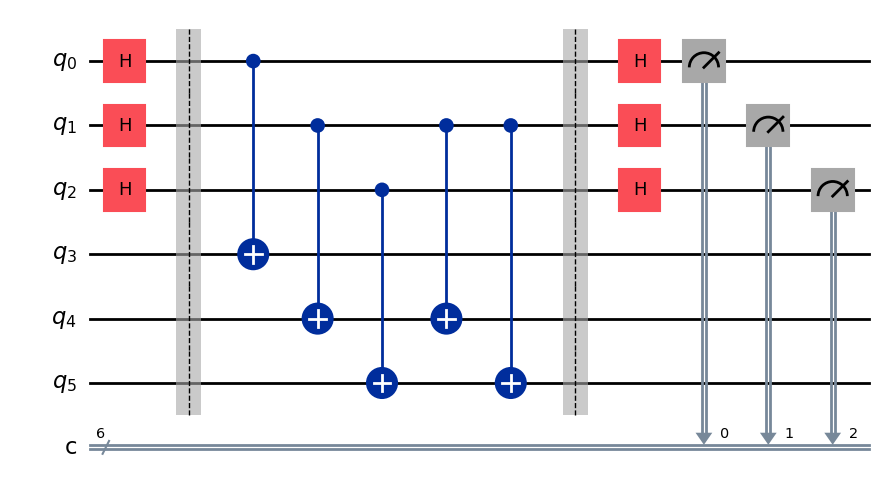

In [7]:
b = '110'
n = len(b)


def simon_oracle(b, n):
    """返回针对比特串b的Simon oracle"""
    b = b[::-1]  # 将b反转以便于迭代
    cir = dq.QubitCircuit(n * 2)

    # 执行复制；|x>|0> -> |x>|x>
    for q in range(n):
        cir.cx(q, q + n)

    if '1' not in b:
        return cir  # 1:1映射，所以直接退出

    i = b.find('1')  # 在b中找到第一个非零比特的索引

    # 如果q_i是1，则执行|x> -> |s.x>
    for q in range(n):
        if b[q] == '1':
            cir.cx(i, q + n)

    return cir


def simon_algorithm(b, n):
    simon_circuit = dq.QubitCircuit(n * 2)

    # 在查询oracle之前应用Hadamard门
    for i in range(n):
        simon_circuit.h(i)

    simon_circuit.barrier()

    # 应用oracle
    simon_circuit += simon_oracle(b, n)

    simon_circuit.barrier()

    # 对输入寄存器应用Hadamard门
    for i in range(n):
        simon_circuit.h(i)

    # 测量量子比特
    simon_circuit.measure(wires=list(range(n)))

    return simon_circuit


cir = simon_algorithm(b, n)
cir.draw()

### 进行实验
我们可以在模拟器上运行上述线路。

In [8]:
cir()
res = cir.measure(wires=list(range(n)))
res_reversed = {key[::-1]: value for key, value in res.items()}
print(res_reversed)

{'110': 276, '000': 260, '111': 254, '001': 234}


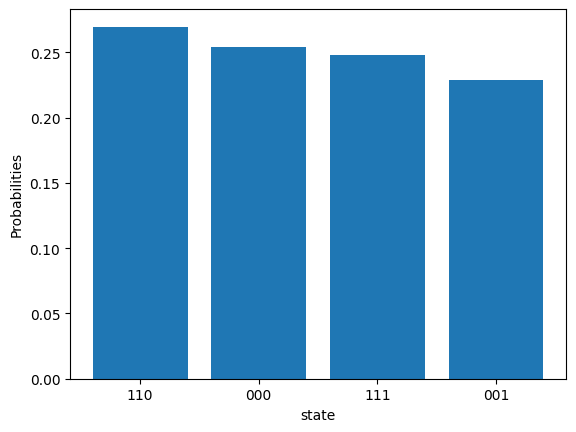

In [9]:
# 键和值分别作为X轴和Y轴数据
keys = list(res_reversed.keys())
total = sum(res_reversed.values())
# 计算每个值相对于总和的比例
values = [value / total for value in res_reversed.values()]

# 创建柱状图
plt.bar(keys, values)

# 添加标题和轴标签
plt.xlabel('state')
plt.ylabel('Probabilities')

# 显示图形
plt.show()

由于我们已经知道了 $b$，我们可以验证这些结果确实满足 $b\cdot z  = 0 \pmod{2}$：

In [10]:
# 计算结果的点积
def bdotz(b, z):
    return sum(int(b_i) * int(z_i) for b_i, z_i in zip(b, z, strict=False)) % 2


# 假设res_reversed是一个包含结果的字典
# 遍历res_reversed的键，并打印b和z的点积（模2）
for z in res_reversed:
    print(f'{b}.{z} = {bdotz(b, z)} (mod 2)')

110.110 = 0 (mod 2)
110.000 = 0 (mod 2)
110.111 = 0 (mod 2)
110.001 = 0 (mod 2)


利用这些结果，我们可以通过解这组同时方程来找回 $b = 110$ 的值。例如，假设我们首次测量得到 `001`，这告诉我们：


$$
\begin{aligned}
b \cdot 001 &= 0 \\
(b_2 \cdot 0) + (b_1 \cdot 0) + (b_0 \cdot 1) & = 0 \\
(\cancel{b_2 \cdot 0}) + (\cancel{b_1 \cdot 0}) + (b_0 \cdot 1) & = 0 \\
b_0 & = 0\\
\end{aligned}
$$

如果我们接下来测量 `111`，我们得到：

$$
\begin{aligned}
b \cdot 111 &= 0 \\
(b_2 \cdot 1) + (b_1 \cdot 1) + (0 \cdot 1) & = 0 \\
(b_2 \cdot 1) + (b_1 \cdot 1) + (\cancel{0 \cdot 1}) & = 0 \\
(b_2 \cdot 1) + (b_1 \cdot 1) & = 0 \\
\end{aligned}
$$


这告诉我们可能是：

$$ b_2 = b_1 = 0, \quad b = 000 $$

或者

$$ b_2 = b_1 = 1, \quad b = 110 $$

其中 $b  = 110$ 是我们同时方程的非平凡解。我们可以使用[高斯消元法](https://mathworld.wolfram.com/GaussianElimination.html)来解决这些问题，其运行时间为 $O(n^3)$。


# 附录（References）
[1] Simon D R. On the power of quantum computation[J]. SIAM journal on computing, 1997, 26(5): 1474-1483.

[2] Cai G, Qiu D. Optimal separation in exact query complexities for Simon's problem[J]. Journal of computer and system sciences, 2018, 97: 83-93.